# **Final Project: HR Analytics Employee Attrition & Performance with Python Data Analytics**

**Student Name:** Yuliia Chernysheva  
**Date:** May 2nd, 2026  
**Course:** Python Data Analytics  
**Dataset:** IBM HR Analytics Employee Attrition & Performance  

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset  

## **Project Overview**

This project utilizes Python, pandas, NumPy, and Matplotlib to explore the IBM HR Analytics dataset. The goal of this analysis is to identify the key factors that lead to employee attrition (turnover) and to understand how different workplace stressors and demographic factors interact.

The scope of the study includes:

* **Employee Demographics:** Age, Marital Status, and Education.
* **Work Environment:** Business Travel frequency, Overtime, and Distance from Home.
* **Financial Factors:** Monthly Income and Salary Hike.
* **Retention Patterns:** How compensation mitigates the impact of high-stress factors like frequent travel and overtime.
* **Commute Impact:** How life stages (age and marital status) moderate the relationship between commute distance and attrition.

This notebook is developed for the Python Data Analytics course at Sinclair Community College. The project focuses on data cleaning, advanced visualization, and providing actionable insights for HR management.

# **Research Report: Introduction**

Employee attrition refers to the phenomenon of employees leaving an organization. For any company, high turnover is a critical issue, as it leads to the loss of institutional knowledge and significant financial costs related to recruiting and training new staff.

HR professionals and business leaders study attrition data to better understand:

* **The Drivers of Turnover:** Which factors, such as workplace stress, compensation, or commute distance, are the primary reasons employees leave.
* **The Effectiveness of Retention Strategies:** Whether higher financial compensation can successfully mitigate the negative effects of high-stress conditions like frequent travel or overtime.
* **The Role of Life Stages:** How a person’s age or marital status changes their tolerance for professional strain, such as a long distance from home.
* **Actionable Insights:** How to identify "at-risk" groups and implement policies that improve work-life balance and employee satisfaction.

This project focuses on variables that provide clear business value: Monthly Income, Overtime, Business Travel frequency, Distance from Home, Age, and Marital Status. Through the analysis of these data points, recommendations are developed to assist organizations in reducing turnover and improving long-term operational performance.

## **Environment Setup and Data Loading**

The initial phase of the project involves preparing the Python environment. Necessary libraries for data manipulation and statistical visualization are imported, and display configurations are adjusted to ensure full visibility of the dataset's features during the exploratory analysis.

Libraries used:

* **Pandas:** For data structures and data analysis.
* **NumPy:** For numerical operations.
* **Matplotlib & Seaborn:** For creating high-quality statistical graphics and visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Display charts inside the notebook
%matplotlib inline

# Remove the limit on the number of displayed columns
pd.set_option('display.max_columns', None)

## **Data Acquisition and Initial Exploration**

The process begins with loading the IBM HR Analytics Employee Attrition & Performance dataset. This dataset is a synthetic resource developed by IBM data scientists to identify underlying factors that influence employee turnover.

The initial exploration focuses on:

* **Dataset Dimensions:** Verification of the total number of records (observations) and variables (features).
* **Data Preview:** Examination of the first few rows to understand the structure, column names, and data types (categorical vs. numerical).
* **Verification:** Ensuring the file was loaded correctly into the Pandas DataFrame.

In [2]:
file_name = 'Employee_Attrition.csv'

df = pd.read_csv(file_name)

# Show the number of rows and columns
print(">> Rows and columns:", df.shape)

print("\n>> The first few records from the Employee_Attrition dataset")
display(df.head())

>> Rows and columns: (1470, 35)

>> The first few records from the Employee_Attrition dataset


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## **Variable Identification and Data Audit**

Following the data load, a comprehensive inspection of the available features is conducted. The dataset contains a diverse range of variables, including employee demographics, job-related metrics, and compensation structures.

The objectives of this audit are to:

* **Inventory Features:** Document all 35 variables to understand the scope and breadth of the available data.
* **Assess Relevance:** Identify critical variables aligned with the research questions, specifically MonthlyIncome, OverTime, BusinessTravel, Age, and MaritalStatus.
* **Technical Filtration:** Detect redundant variables or those with zero variance (e.g., columns containing a single unique value) that do not contribute to the analytical depth of the project.

This audit ensures the availability of high-quality data points necessary to construct an actionable report, adhering to the professional standards outlined in the project guidelines.

In [3]:
# Check data types and identify numerical vs categorical variables
print(">> Variable Types:")
print(df.dtypes.value_counts())

# Show all column names
print("\n>> List of variables in the dataset:")
df.columns.tolist()

>> Variable Types:
int64     26
object     9
Name: count, dtype: int64

>> List of variables in the dataset:


['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

# **Data Preparation & Cleaning**
## **Feature Selection for Focused Analysis**

To ensure the analysis remains focused on the core research questions, a subset of the original data is selected. This approach reduces noise and concentrates on the variables most relevant to workplace stressors, financial compensation, and employee demographics.

| Original Column | Description | Relevance | 
|---|---|---|
| `Attrition` | Employee turnover status (Yes/No) | Target variable for the analysis |
| `OverTime` | Whether an employee works beyond standard hours | Key workplace stressor |
| `BusinessTravel` | Frequency of professional travel | Key workplace stressor |
| `MonthlyIncome` | Gross monthly salary (USD) | Primary mitigating financial factor |
| `MaritalStatus` | Marital status (Single, Married, Divorced) | Demographic moderator for life-stage analysis |
| `Age` | Employee age in years | Demographic moderator for life-stage analysis |
| `DistanceFromHome` | Distance between residence and office | Primary factor for commute strain analysis |

In [4]:
# Define variables relevant to the research questions
selected_columns = [
    'Attrition', 
    'OverTime', 
    'BusinessTravel', 
    'MonthlyIncome', 
    'MaritalStatus', 
    'Age', 
    'DistanceFromHome'
]

# Create a filtered DataFrame for analysis
df_attrition = df[selected_columns].copy()

# Summary of the filtered dataset
print(f">> Total features selected: {df_attrition.shape[1]}")
print(f">> Total observations: {df_attrition.shape[0]}")

display(df_attrition.head())

>> Total features selected: 7
>> Total observations: 1470


,Attrition,OverTime,BusinessTravel,MonthlyIncome,MaritalStatus,Age,DistanceFromHome
0,Yes,Yes,Travel_Rarely,5993,Single,41,1
1,No,No,Travel_Frequently,5130,Married,49,8
2,Yes,Yes,Travel_Rarely,2090,Single,37,2
3,No,Yes,Travel_Frequently,2909,Married,33,3
4,No,No,Travel_Rarely,3468,Married,27,2


## **Data Refinement: Renaming for Readability**

To enhance the clarity of the analysis and ensure that all visualizations are professional and self-explanatory, the column names are updated. Replacing compact, technical nomenclature with descriptive titles facilitates better interpretation of the results for stakeholders.

In [5]:
# Define a mapping for improved readability
rename_map = {
    'Attrition': 'Attrition',
    'OverTime': 'Overtime',
    'BusinessTravel': 'Business Travel',
    'MonthlyIncome': 'Monthly Income',
    'MaritalStatus': 'Marital Status',
    'Age': 'Age',
    'DistanceFromHome': 'Distance From Home'
}

# Apply the rename mapping to the DataFrame
df_attrition = df_attrition.rename(columns=rename_map)

# Display the updated columns and data types to verify changes
print(">> Updated Column Names and Data Types:")
print(df_attrition.dtypes)
print("-" * 30)
display(df_attrition.head())

>> Updated Column Names and Data Types:
Attrition             object
Overtime              object
Business Travel       object
Monthly Income         int64
Marital Status        object
Age                    int64
Distance From Home     int64
dtype: object
------------------------------


,Attrition,Overtime,Business Travel,Monthly Income,Marital Status,Age,Distance From Home
0,Yes,Yes,Travel_Rarely,5993,Single,41,1
1,No,No,Travel_Frequently,5130,Married,49,8
2,Yes,Yes,Travel_Rarely,2090,Single,37,2
3,No,Yes,Travel_Frequently,2909,Married,33,3
4,No,No,Travel_Rarely,3468,Married,27,2


## **Data Quality Assessment: Missing Value Analysis**

To ensure the integrity of the statistical analysis and the reliability of the resulting inferences, a thorough assessment of data completeness is required.

The following procedure is executed:

* **Completeness Audit:** Calculation of the total number of missing entries for each selected variable.
* **Validation:** Verification that the dataset is ready for analysis without the need for imputation or record exclusion.

In [6]:
# Check for missing values in the refined dataset
missing_values = df_attrition.isnull().sum()

# Display the count of missing values for each column
print(">> Missing Values per Column:")
print(missing_values)

# Verify if there are any total missing values in the dataframe
total_missing = missing_values.sum()
print("-" * 30)
print(f">> Total missing entries: {total_missing}")

>> Missing Values per Column:
Attrition             0
Overtime              0
Business Travel       0
Monthly Income        0
Marital Status        0
Age                   0
Distance From Home    0
dtype: int64
------------------------------
>> Total missing entries: 0


## **Data Integrity: Duplicate Record Analysis**

The presence of duplicate records can lead to overrepresented observations and skewed statistical results. To ensure the reliability of the analysis, a check for exact duplicates is conducted. Removing redundant rows is a standard procedure to maintain the integrity of the unique employee entries within the dataset.

The process includes:

* **Redundancy Audit:** Identifying any rows where all variables contain identical values.
* **Data Sanitization:** Removing identified duplicates to produce a finalized, unique dataset for exploratory analysis.

In [7]:
# Calculate the number of duplicate entries
duplicate_count = df_attrition.duplicated().sum()
print(f">> Duplicate records identified: {duplicate_count}")

# Conditional removal of duplicates to preserve data uniqueness
if duplicate_count > 0:
    df_attrition = df_attrition.drop_duplicates()
    print(f">> Action: {duplicate_count} duplicates removed.")
    print(f">> New dataset dimensions: {df_attrition.shape}")
else:
    print(">> Action: No duplicate records found. Dataset integrity verified")

# Display final verification
print("-" * 30)
print(f"Final observation count: {df_attrition.shape[0]}")

>> Duplicate records identified: 0
>> Action: No duplicate records found. Dataset integrity verified
------------------------------
Final observation count: 1470


## **Data Transformation: Categorical Encoding**

To facilitate quantitative analysis and enable the use of statistical functions, categorical variables are converted into a numerical format. This process, specifically applied to the Attrition and Overtime features, transforms binary text labels into a machine-readable "0 and 1" structure.

The transformation logic is as follows:

* **Yes → 1:** Indicates the presence of the attribute (e.g., the employee has left the company or works overtime).
* **No → 0:** Indicates the absence of the attribute.

This reformatting is essential for calculating attrition rates and evaluating the correlation between workplace stressors and financial factors.

In [8]:
# Map categorical 'Yes'/'No' values to numerical 1/0
df_attrition['Attrition'] = df_attrition['Attrition'].map({'Yes': 1, 'No': 0})
df_attrition['Overtime'] = df_attrition['Overtime'].map({'Yes': 1, 'No': 0})

# Verify the transformation and check data types
print(">> Data Transformation Summary:")
print(df_attrition[['Attrition', 'Overtime']].dtypes)
print("-" * 30)
display(df_attrition.head())

>> Data Transformation Summary:
Attrition    int64
Overtime     int64
dtype: object
------------------------------


,Attrition,Overtime,Business Travel,Monthly Income,Marital Status,Age,Distance From Home
0,1,1,Travel_Rarely,5993,Single,41,1
1,0,0,Travel_Frequently,5130,Married,49,8
2,1,1,Travel_Rarely,2090,Single,37,2
3,0,1,Travel_Frequently,2909,Married,33,3
4,0,0,Travel_Rarely,3468,Married,27,2


## **Final Data Validation: Structural Integrity Check**

Prior to executing the Exploratory Data Analysis (EDA), a final validation of the data types is performed. This step ensures that all numerical variables (e.g., Monthly Income, Age) and encoded binary features (Attrition, Overtime) are correctly recognized by the Python environment.

Confirming the structural integrity of the DataFrame prevents errors in statistical calculations and ensures that visualization libraries (Matplotlib/Seaborn) interpret the data scales accurately.

In [9]:
# Final verification of data types before analysis
print(">> Final Data Audit:")
print(df_attrition.dtypes)

# Display a summary of numerical characteristics
print("-" * 30)
print(">> Numerical Summary:")
display(df_attrition.describe().round(2))

>> Final Data Audit:
Attrition              int64
Overtime               int64
Business Travel       object
Monthly Income         int64
Marital Status        object
Age                    int64
Distance From Home     int64
dtype: object
------------------------------
>> Numerical Summary:


,Attrition,Overtime,Monthly Income,Age,Distance From Home
count,1470.00,1470.00,1470.00,1470.00,1470.00
mean,0.16,0.28,6502.93,36.92,9.19
std,0.37,0.45,4707.96,9.14,8.11
min,0.00,0.00,1009.00,18.00,1.00
25%,0.00,0.00,2911.00,30.00,2.00
50%,0.00,0.00,4919.00,36.00,7.00
75%,0.00,1.00,8379.00,43.00,14.00
max,1.00,1.00,19999.00,60.00,29.00


# **Research Report: Methods**

This project utilizes a synthetic dataset generated by IBM data scientists, designed to simulate real-world employee performance and attrition patterns. While the data is artificial, it maintains the logical correlations found in professional human resources environments, making it a robust tool for demonstrating analytical techniques.

The data preparation and cleaning process involved the following steps:

1. **Data Acquisition:** Loading the synthetic CSV file from the IBM HR Analytics repository into the Pandas environment.
2. **Initial Exploration:** Previewing observations and identifying the structural dimensions of the dataset.
3. **Feature Selection:** Selecting a focused subset of variables relevant to the research questions (e.g., Monthly Income, Overtime, and Distance From Home).
4. **Descriptive Renaming:** Updating column nomenclature to ensure clarity and professional presentation by replacing technical headers with descriptive labels.
5. **Quality Assessment:** Verifying the absence of missing values (nulls) to maintain the integrity of the synthetic observations.
6. **Data Integrity Check:** Identifying and removing duplicate records to ensure each entry represents a unique simulated employee.
7. **Categorical Encoding:** Converting binary categorical features (Attrition, Overtime) into numerical format (0 and 1) for quantitative analysis.
8. **Statistical Visualization:** Utilizing Matplotlib and Seaborn to generate high-quality graphics for pattern recognition and data interpretation.

The methodology emphasizes data-driven interpretation of the simulated environment, prioritizing the communication of identified patterns over complex mathematical modeling.

# Visualization Configuration and Styling

To ensure a professional and cohesive aesthetic throughout the report, a standardized visual theme is established. Consistent color schemes and typography not only enhance readability but also ensure that the charts are suitable for stakeholder presentations. The following settings prioritize clarity, removing unnecessary chart elements (such as top and right spines) to focus the viewer's attention on the data patterns.

Styling Principles Applied:

* **Color Consistency:** Defined primary and secondary colors for attrition and retention.
* **Minimalist Design:** Removal of chart "chart junk" to improve the data-to-ink ratio.
* **Typography:** Standardized font sizes for titles and labels to ensure legibility in a professional report.

In [10]:
# Define a professional corporate color palette
COLOR_PRIMARY = '#0077B6'  # Professional Blue (e.g., for 'No Attrition')
COLOR_ACCENT = '#E63946'   # Soft Red (e.g., for 'Attrition')
COLOR_TEXT = '#2F2F2F'     # Dark Grey for readability
COLOR_GRID = '#E0E0E0'     # Light Grey for subtle grids

# Global Style Settings for high-quality visualizations
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': COLOR_GRID,
    'axes.labelcolor': COLOR_TEXT,
    'text.color': COLOR_TEXT,
    'xtick.color': COLOR_TEXT,
    'ytick.color': COLOR_TEXT,
    'font.size': 12,
    'axes.titlesize': 18,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,    # Remove top border for a modern look
    'axes.spines.right': False,  # Remove right border
    'axes.grid': True,           # Enable grid
    'grid.alpha': 0.3,           # Set grid transparency
    'grid.color': COLOR_GRID
})

print(">> Visualization theme successfully applied")

>> Visualization theme successfully applied


# **Research Findings and Analysis**

This section presents the results of the exploratory data analysis, focusing on the research questions regarding workplace stressors, financial compensation, and demographic factors.

## **Baseline Attrition Analysis: Overall Departure Ratio**

Before examining specific stressors, the baseline attrition rate within the organization is established. This overall perspective serves as a benchmark for comparing at-risk subgroups (e.g., those with high overtime or long commutes).

The following visualization illustrates:

* The proportion of employees who remained with the company (`Stayed`) versus those who departed (`Left`).
* The specific percentage distribution, providing a clear metric of the organizational turnover rate.

>> Table 1: Overall Attrition Summary
           Quantity  Percentage (%)
Attrition                          
Stayed         1233            83.9
Left            237            16.1
------------------------------


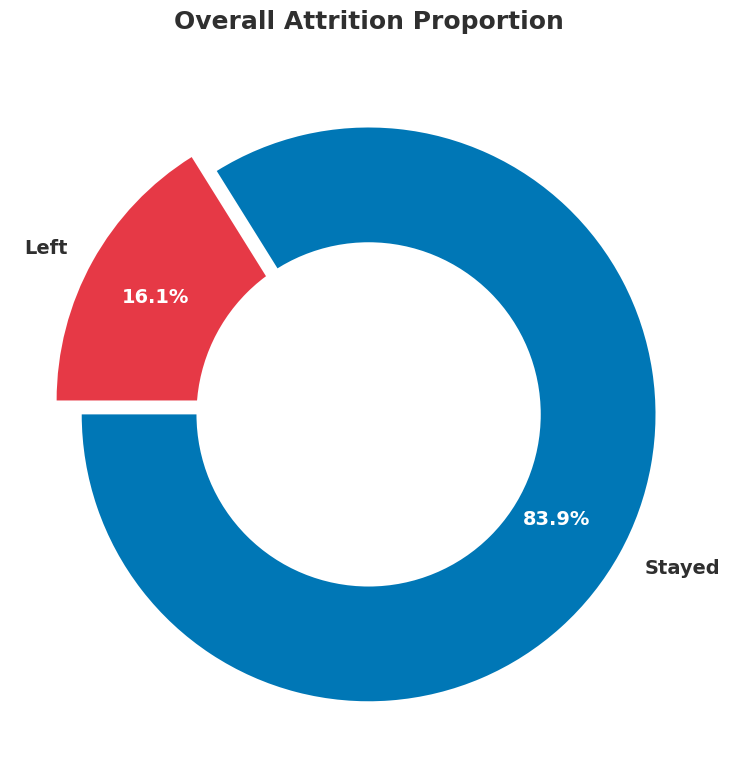

In [11]:
# Count the occurrences of each status (0 = Stayed, 1 = Left)
attrition_counts = df_attrition['Attrition'].value_counts()
attrition_prc = df_attrition['Attrition'].value_counts(normalize=True)*100

# Create a summary table for professional reporting
summary_df = pd.DataFrame({
    'Quantity': attrition_counts, 
    'Percentage (%)': attrition_prc
})

# Map indices to descriptive labels for readability
summary_df.index = summary_df.index.map({0: 'Stayed', 1: 'Left'})

# Display the summary table
print(">> Table 1: Overall Attrition Summary")
print(summary_df.round(1))
print("-" * 30)

# Define labels and sizes for the chart
labels = summary_df.index
sizes = summary_df['Quantity']

# Create the donut chart using subplots
fig, ax = plt.subplots(figsize=(8, 8))

# Draw the main pie chart
wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels,                                   
    autopct='%1.1f%%', 
    shadow=False,
    startangle=180, 
    colors=[COLOR_PRIMARY, COLOR_ACCENT],
    explode=(0, 0.1), # Offset the 'Left' segment for emphasis
    pctdistance=0.75, 
    textprops={'fontweight': 'bold', 'fontsize': 14}
)

# Draw a central white circle to transform the pie into a donut
centre_circle = plt.Circle((0,0), 0.60, fc='white')
ax.add_artist(centre_circle)

# Format chart titles and labels
ax.set_title('Overall Attrition Proportion', 
             fontweight='bold', pad=20)

# Ensure the percentages are visible on the colored backgrounds
for autotext in autotexts:
    autotext.set_color('white')

plt.tight_layout()
plt.show()

## **Analysis of Research Question 1: Workplace Stressors and Financial Mitigation**

*Research Question:* **To what extent does Monthly Income act as a mitigating factor for attrition among employees with high Overtime and frequent Business Travel?**

The analysis begins by isolating the impact of Overtime on attrition rates. Identifying the baseline risk associated with extended work hours is essential before evaluating how financial compensation might reduce this risk.

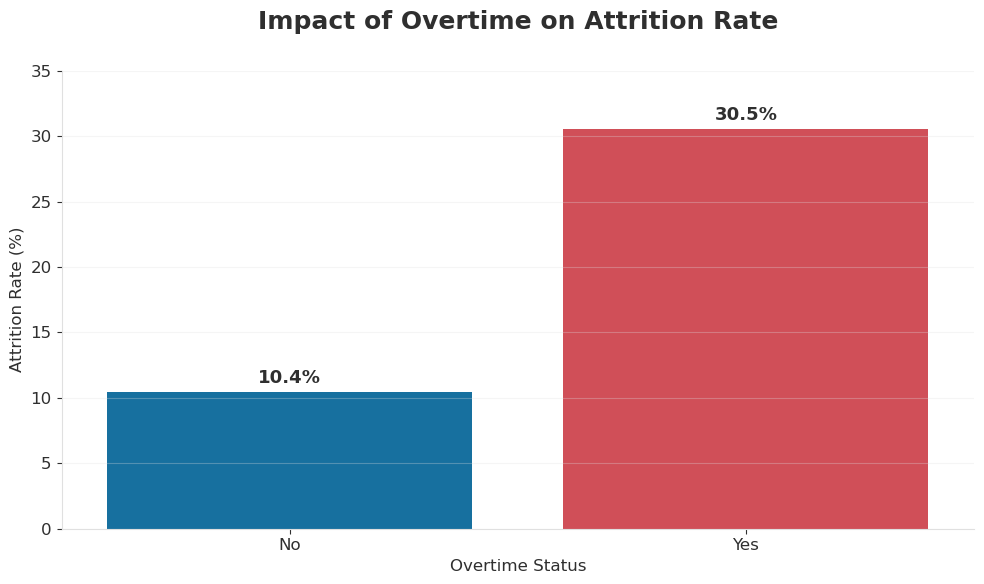

In [12]:
# Data Preparation
# Calculate the attrition rate (percentage) grouped by Overtime status
overtime_attrition = df_attrition.groupby('Overtime')['Attrition'].mean()*100

# Convert Series to DataFrame for easier plotting with Seaborn
ot_data = overtime_attrition.reset_index()
ot_data['Overtime'] = ot_data['Overtime'].map({1: 'Yes', 0: 'No'})

# Visualization 
plt.figure(figsize=(10, 6))

# Create a bar plot
ax = sns.barplot(
    x='Overtime', 
    y='Attrition', 
    data=ot_data, 
    palette=[COLOR_PRIMARY, COLOR_ACCENT],
    hue='Overtime',
    legend=False
)

# Add percentage labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=13, fontweight='bold', 
                color=COLOR_TEXT, xytext=(0, 10), 
                textcoords='offset points')

# Format the chart
plt.title('Impact of Overtime on Attrition Rate', pad=30)
plt.xlabel('Overtime Status')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 35) # Add space for labels

# Display the plot
plt.tight_layout()
plt.show()

**Interpretation: Overtime as a Primary Driver of Attrition**

The initial comparative analysis confirms a strong positive correlation between extended work hours and employee turnover. By isolating the overtime variable, a clear baseline risk is identified, providing the necessary context for evaluating financial mitigation.

Key Observations from the Data:

* **Risk Magnification:** Employees required to work Overtime exhibit a substantially higher attrition rate of **30.5%**, compared to only **10.4%** for those who do not.
* **Three-Fold Increase:** The probability of an employee departing the organization is approximately three times higher when overtime is present.
* **Identification of "At-Risk" Population:** These results establish overtime as a primary catalyst for attrition, confirming that nearly one in three employees in this category will leave the company.

This baseline confirms that overtime is a critical stressor. The subsequent analysis will determine to what extent higher Monthly Income levels act as a successful buffer to retain employees within this high-risk subgroup.

### **Financial Mitigation: Income Distribution Among Overtime Employees**

To determine if Monthly Income acts as a mitigating factor, the analysis focuses specifically on the subgroup of employees who work Overtime. By comparing the income levels of those who stayed versus those who departed within this high-stress category, it is possible to observe whether higher compensation correlates with increased retention.

The following visualization examines:

* The median income and interquartile range (IQR) for both groups within the Overtime category.
* Whether a significant "pay gap" exists between retained and attrited employees facing the same workplace stressor.

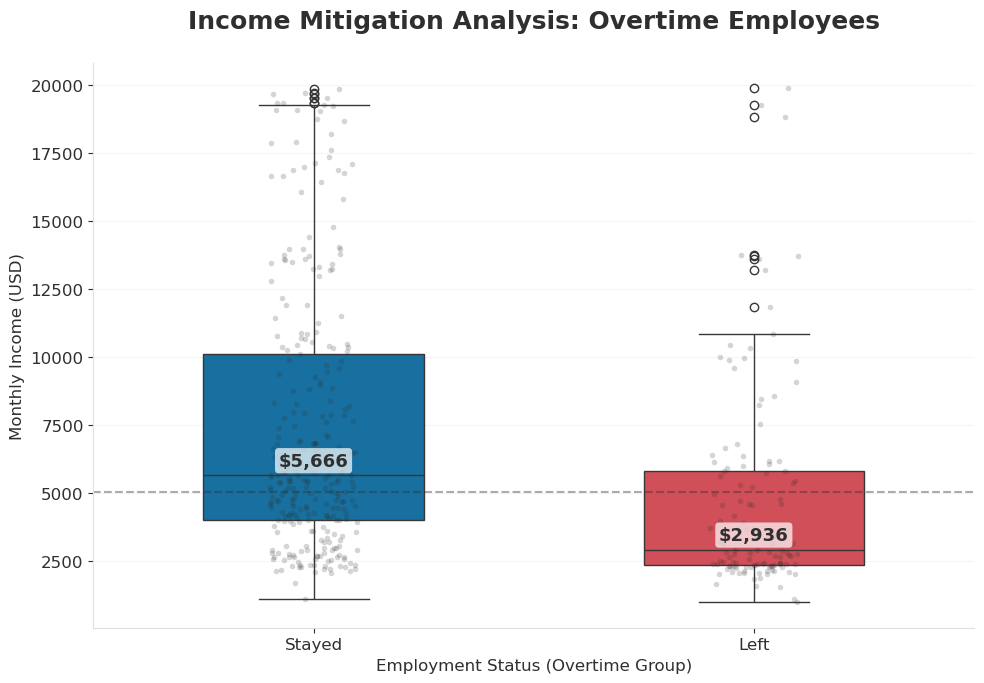

In [13]:
# Filter the dataset to include only employees who work Overtime
overtime_subgroup = df_attrition[df_attrition['Overtime'] == 1].copy()
overtime_subgroup['Status'] = overtime_subgroup['Attrition'].map({1: 'Left', 0: 'Stayed'})

# Order Fixation: Stayed (0) on the left, Left (1) on the right
group_order = ['Stayed', 'Left']

# Calculation of medians in strict accordance with the selected order
overtime_medians = overtime_subgroup.groupby('Status')['Monthly Income'].median().reindex(group_order)

# Visualization
plt.figure(figsize=(10, 7))

# Create a boxplot
ax = sns.boxplot(
    x='Status', 
    y='Monthly Income', 
    data=overtime_subgroup, 
    order=group_order,
    palette=[COLOR_ACCENT, COLOR_PRIMARY],
    hue='Status',
    legend=False,
    width=0.5,
    linewidth=1
)

# Add a swarmplot on top to show individual data points (optional, adds depth)
sns.stripplot(
    x='Status', 
    y='Monthly Income', 
    data=overtime_subgroup, 
    order=group_order,
    color=COLOR_TEXT, 
    alpha=0.2, 
    size=4
)

# Dynamic Annotations 
for i, status in enumerate(group_order):
    m_val = overtime_medians[status]
    
    # Adding text above the median line
    ax.text(
        i, 
        m_val + 200, # Vertical offset for readability
        f'${m_val:,.0f}', 
        ha='center', 
        va='bottom', 
        fontweight='bold', 
        fontsize=13,
        color=COLOR_TEXT,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', 
                  boxstyle='round,pad=0.2')
    )

# Format the chart
plt.title('Income Mitigation Analysis: Overtime Employees', pad=25)
plt.xlabel('Employment Status (Overtime Group)')
plt.ylabel('Monthly Income (USD)')

# Add a horizontal line for the overall median income for context
subgroup_median = overtime_subgroup['Monthly Income'].median()
plt.axhline(subgroup_median, color=COLOR_TEXT, linestyle='--', 
            alpha=0.4, label='Subgroup Median')

plt.tight_layout()
plt.show()

**Interpretation of Results: Income as a Mitigating Factor**

The boxplot analysis of the overtime-intensive subgroup provides critical insights into the relationship between financial compensation and employee retention.

Key Observations:

* **Income Disparity:** There is a visible gap in the median monthly income between the two groups. Employees who remained with the organization (Stayed) consistently exhibit higher income levels compared to those who departed (Left).
* **Attrition Concentration:** The majority of employees who left the company while working overtime are concentrated in the lower-income brackets (typically below $5,000).
* **Outlier Influence:** The "Stayed" group contains several high-income outliers, suggesting that specialized or senior roles with high compensation are highly resilient to the stressors of overtime.

*Key Insight: Monthly Income as a Buffer against Burnout*

The data indicates that Monthly Income acts as a critical moderator. While overtime increases the overall risk of attrition, higher financial rewards appear to offset this stressor. Employees receiving competitive compensation (above the identified median) are significantly more likely to tolerate extended work hours, whereas those in lower-pay tiers facing the same workload have a much higher probability of departure.

### **Impact of Travel Frequency on Turnover**

Business travel represents another significant workplace stressor identified in Research Question 1. The following analysis examines how the frequency of professional travel correlates with attrition rates. By utilizing a Lollipop Chart, the disparity between "Travel Frequently" and other categories is clearly visualized, providing a focus for potential HR policy adjustments.

Key features of this visualization:

* **Clear Hierarchy:** Categories are sorted by attrition rate to emphasize the highest risk group.
* **Data Precision:** Exact percentage labels are provided for immediate interpretation.

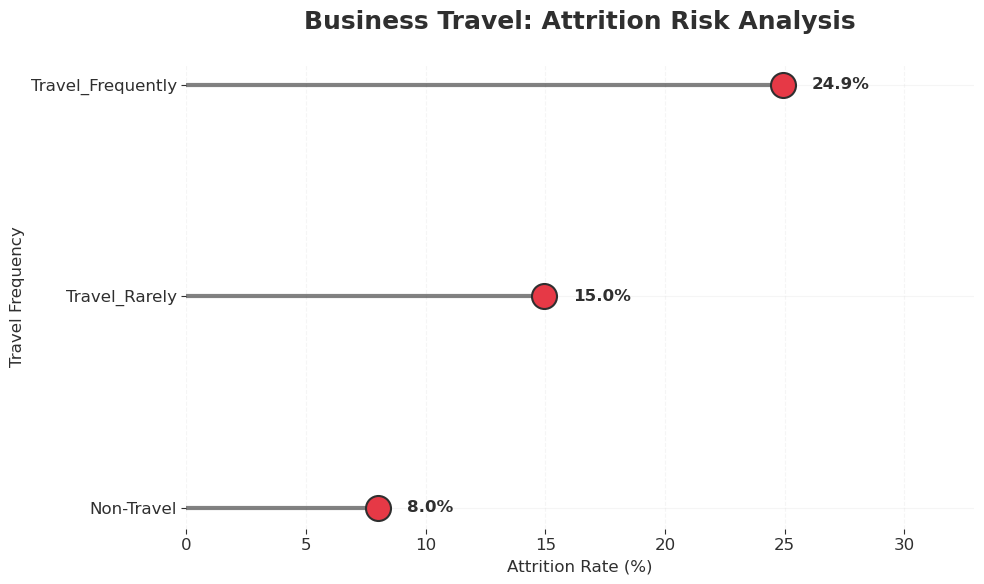

In [14]:
# Group by the renamed column 'Business Travel' and calculate the mean attrition rate
travel_attrition = df_attrition.groupby('Business Travel')['Attrition'].mean().sort_values()*100

# Visualization 
plt.figure(figsize=(10, 6))

# Draw the lollipop "sticks" 
plt.hlines(
    y=travel_attrition.index, 
    xmin=0, 
    xmax=travel_attrition.values,
    color=COLOR_TEXT, 
    alpha=0.6, 
    linewidth=3
)

# Draw the "Lollipops" 
plt.plot(
    travel_attrition.values, 
    travel_attrition.index, 
    "o",
    markersize=18, 
    color=COLOR_ACCENT, 
    markeredgecolor=COLOR_TEXT, 
    markeredgewidth=1.5
)

# Add percentage labels directly to the right of the markers
for i, v in enumerate(travel_attrition.values):
    plt.text(
        v + 1.2, 
        i, 
        f"{v:.1f}%", 
        va='center', 
        fontweight='bold',
        fontsize=12, 
        color=COLOR_TEXT
    )

# Format the chart axes and titles
plt.title('Business Travel: Attrition Risk Analysis', pad=25)
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Travel Frequency')

# Adjust limits and grid
plt.xlim(0, travel_attrition.max() + 8) 
plt.grid(axis='x', linestyle='--', alpha=0.3, color=COLOR_GRID)
plt.box(False)

plt.tight_layout()
plt.show()

**Interpretation of Results:** Business Travel as a Risk Factor

The analysis of the relationship between travel frequency and attrition reveals a significant disparity between the groups. The Lollipop chart demonstrates that as professional mobility requirements increase, the likelihood of employee departure rises proportionally.

Key Observations from the Data:

* **Highest Risk Concentration:** Employees who Travel Frequently exhibit the highest attrition rate within the dataset, recorded at approximately **24.9%**.
* **The Baseline Comparison:** The attrition rate for frequent travelers is more than three times higher than that of the Non-Travel group (**8.0%**), establishing frequent travel as a primary risk indicator.
* **Incremental Risk:** A clear "travel gradient" is visible: the transition from no travel to Rare Travel (**15.0%**) nearly doubles the attrition probability, while the shift to frequent travel nearly triples it.
* **Impact on Stability:** The data indicates that roles with high travel demands are inherently more volatile, suggesting that the strain of professional mobility is a major contributor to the organization’s overall turnover rate.

### **Financial Mitigation: Income Distribution Among Frequent Travelers**

To conclude the investigation into Research Question 1, it is necessary to evaluate if Monthly Income serves as a mitigating factor for employees with high travel requirements. By isolating the "Travel Frequently" subgroup, the analysis examines whether higher compensation levels correlate with increased retention, similar to the patterns observed in the overtime analysis.

The objectives of this visualization are to:

* Compare the median income of employees who stayed versus those who departed within the high-travel category.
* Identify if there is a specific income threshold that facilitates higher retention for mobile roles.

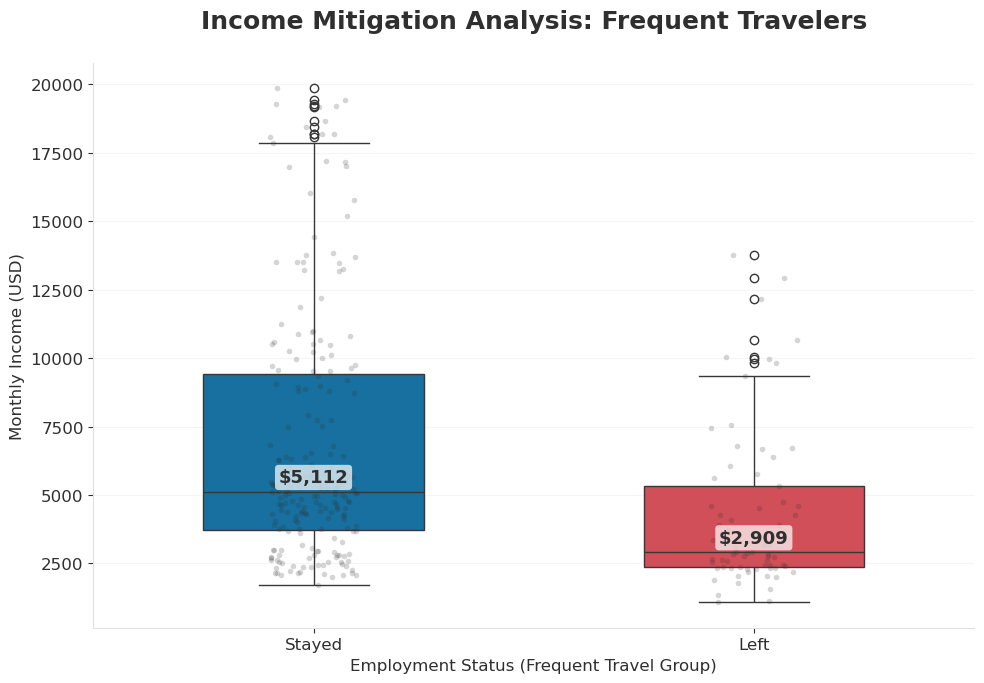

In [15]:
# Filter for employees who travel frequently
travel_subgroup = df_attrition[df_attrition['Business Travel'] == 'Travel_Frequently'].copy()
travel_subgroup['Status'] = travel_subgroup['Attrition'].map({1: 'Left', 0: 'Stayed'})

# Calculate exact median values for annotations
travel_medians = travel_subgroup.groupby('Status')['Monthly Income'].median()

# Visualization
plt.figure(figsize=(10, 7))

# Create the boxplot
ax = sns.boxplot(
    x='Status', 
    y='Monthly Income', 
    data=travel_subgroup, 
    palette=[COLOR_PRIMARY, COLOR_ACCENT],
    hue='Status',
    legend=False,
    width=0.5
)

# Add jittered points for data density
sns.stripplot(x='Status', y='Monthly Income', data=travel_subgroup, 
              color=COLOR_TEXT, alpha=0.2, size=4)

# Dynamic Annotations
for i, status in enumerate(['Stayed', 'Left']):
    m_val = travel_medians[status]
    
    ax.text(
        i, 
        m_val + 200, 
        f'${m_val:,.0f}', 
        ha='center', 
        va='bottom', 
        fontweight='bold', 
        fontsize=13,
        color=COLOR_TEXT,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', 
                  boxstyle='round,pad=0.2')
    )

# Format the chart
plt.title('Income Mitigation Analysis: Frequent Travelers', pad=25)
plt.xlabel('Employment Status (Frequent Travel Group)')
plt.ylabel('Monthly Income (USD)')

plt.tight_layout()
plt.show()

**Interpretation:** Compensation as a Buffer for Travel Strain

The analysis of the "Frequent Travel" subgroup confirms that Monthly Income is a decisive factor in employee retention for high-mobility roles.

Findings:

* **Significant Income Gap:** There is a substantial disparity of nearly `$2,000` dollars between the median income of employees who Stayed (`$5,112`) and those who Left (`$2,909`).
* **Financial Resilience:** The data indicates that employees are significantly more willing to tolerate the stressors associated with frequent business travel if their compensation is above a certain threshold (approximately `$5,000` in this dataset).
* **Vulnerability:** Employees in lower-income brackets are highly susceptible to "travel fatigue," leading to a much higher probability of attrition.

### **Final Summary: Research Question 1**

**Conclusion:** To what extent does Monthly Income act as a mitigating factor for attrition among employees with high Overtime and frequent Business Travel?

The evidence gathered through exploratory data analysis confirms that Monthly Income acts as a primary mitigating factor for workplace stressors. While both Overtime and Frequent Business Travel significantly increase the risk of attrition, this risk is not uniform across all income levels.

* **The Stressor Impact:** Without financial mitigation, overtime and frequent travel nearly triple the baseline attrition rate.
* **The Income Buffer:** Higher compensation levels (median > `$5,000`) effectively "buffer" employees against these stressors, leading to higher retention.
* **Strategic Insight:** The organization's turnover problem is not caused by travel or overtime alone, but by the combination of high stress and low pay. To improve stability, HR interventions should prioritize salary adjustments or retention bonuses specifically for high-travel and high-overtime roles in lower salary grades.

Concluding the analysis of financial moderators, the study now shifts to geographic and demographic factors in Research Question 2.

---
## **Analysis of Research Question 2: Life Stages and Commute Strain**

*Research Question:* **How do Marital Status and Age moderate the relationship between Distance From Home and employee attrition rates?**

This phase of the research investigates the geographical dimension of employment. Specifically, it examines whether the distance between an employee's residence and the workplace serves as a catalyst for departure, and how this relationship is moderated by an employee's life stage, defined by `Marital Status` and `Age`.

### **Distribution of Commute Distance by Marital Status**

The following analysis evaluates the distribution of `Distance From Home` for employees who remained with the organization versus those who departed, segmented by marital status. This visualization aims to identify which demographic groups exhibit the highest sensitivity to commute-related strain..

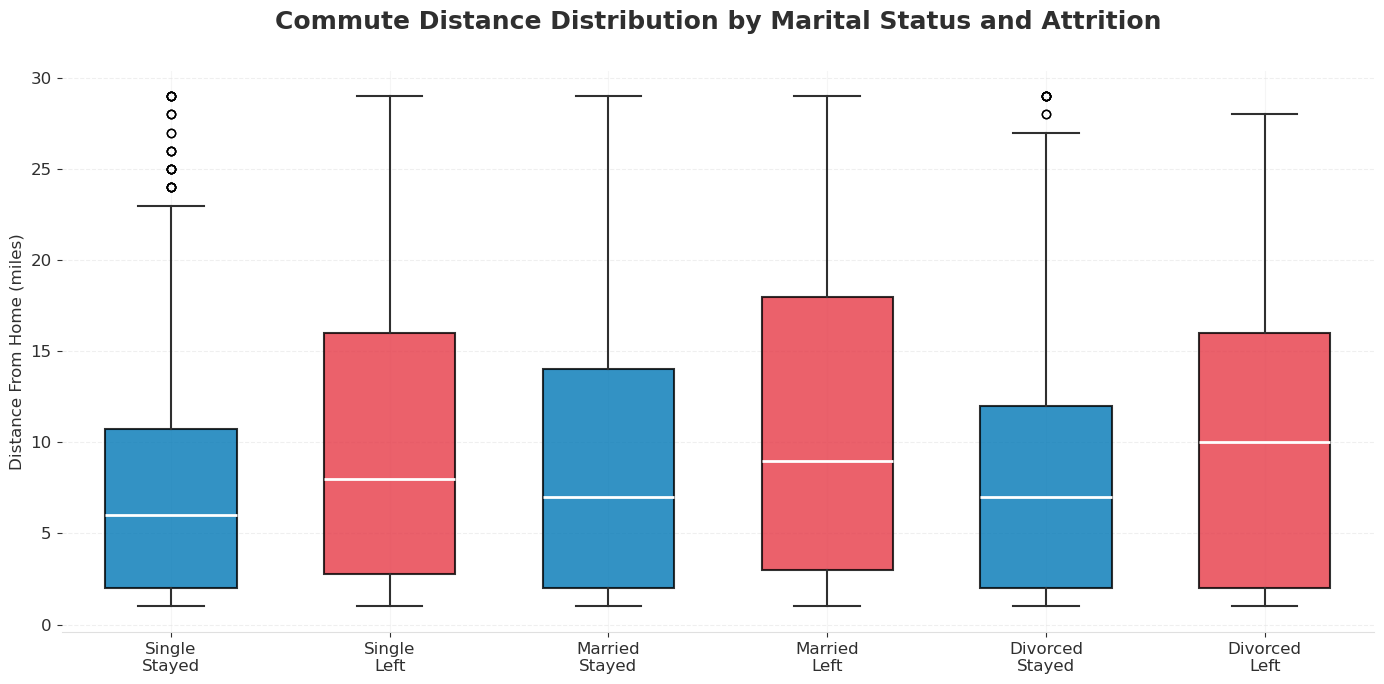

In [16]:
# Data Preparation
statuses = df_attrition['Marital Status'].unique()
data_to_plot = []
labels = []

# Segment distance data by Status and Attrition
for status in statuses:
    # Subset for employees who Stayed (0)
    stayed_dist = df_attrition[(df_attrition['Marital Status'] == status) & (df_attrition['Attrition'] == 0)]['Distance From Home']
    # Subset for employees who Left (1)
    left_dist = df_attrition[(df_attrition['Marital Status'] == status) & (df_attrition['Attrition'] == 1)]['Distance From Home']
    
    data_to_plot.append(stayed_dist)
    data_to_plot.append(left_dist)
    
    # Create clear labels for the X-axis
    labels.extend([f'{status}\nStayed', f'{status}\nLeft'])

# Visualization
plt.figure(figsize=(14, 7))

# Create a box plot
box = plt.boxplot(data_to_plot, 
                  patch_artist=True, 
                  tick_labels=labels, 
                  widths=0.6,
                  medianprops=dict(color='white', linewidth=2), 
                  whiskerprops=dict(color=COLOR_TEXT, linewidth=1.5),
                  capprops=dict(color=COLOR_TEXT, linewidth=1.5),
                  boxprops=dict(linewidth=1.5))

# Coloring the boxes: Primary color for Stayed, Accent for Left
colors = [COLOR_PRIMARY, COLOR_ACCENT] * len(statuses)
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# Formatting
plt.title('Commute Distance Distribution by Marital Status and Attrition', pad=30)
plt.ylabel('Distance From Home (miles)')

# Add grid for easier reading of distances
plt.grid(axis='y', linestyle='--', alpha=0.5, color=COLOR_GRID)

# Remove unnecessary spines for a clean look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

**Analytical Interpretation: Commute Sensitivity**

The distribution analysis reveals a consistent correlation between increased commute distance and employee turnover across all marital categories.

Key Findings:

* **Higher Median Distance for Attrition:** In all three groups (`Single, Married, and Divorced`), the median distance for employees who `Left` is higher than for those who `Stayed`. This visually confirms that distance is a persistent factor in the decision to leave.
* **Maximum Variance in the Married Group:** Interestingly, the `Married` category shows the largest spread (range) of distances among those who left. This indicates that for married employees, the commute factor may be more unpredictable, with departures occurring across a very wide spectrum of distances (from near to very far).
* **Single and Divorced Trends:** For the `Single` and `Divorced` groups, the "Stayed" boxes are very compact and low, showing that retention in these groups is strongest when they live very close to the office.
* **The 10-Mile Threshold:** Across all categories, the majority of retained employees are concentrated within **10 miles** of the workplace. Once this threshold is crossed, a clear increase in the range of attrition cases is observed, regardless of marital status.

### **Feature Engineering: Age and Distance Categorization**

To analyze the interaction between demographics and commute strain, continuous variables are transformed into discrete categories. This process allows for a more granular examination of how different life stages respond to geographic distance.

* **Age Groups:** Segmented into Young (**<30**), Middle (**30-45**), and Senior (**45+**) to represent different career and life stages.
* **Distance Categories:** A threshold of **10 miles** is established to distinguish between `"Near"` and `"Far"` commutes.

In [17]:
# Create Demographic and Distance Categories
# Categorize Age into life stages
df_attrition['Age Group'] = pd.cut(
    df_attrition['Age'], 
    bins=[18, 30, 45, 60], 
    labels=['Young (<30)', 'Middle (30-45)', 'Senior (45+)'],
    include_lowest=True
)

# Categorize Distance into binary strain levels
df_attrition['Dist_Category'] = df_attrition['Distance From Home'].apply(
    lambda x: 'Far (>10 mi)' if x > 10 else 'Near (<10 mi)'
)

# Statistical Pivot Table
# Calculate the mean attrition rate (%) for each combination of factors
pivot_rq2 = df_attrition.pivot_table(observed=True,
    index=['Marital Status', 'Age Group'], 
    columns='Dist_Category', 
    values='Attrition', 
    aggfunc='mean'
) * 100

print(">> Attrition Rate (%) by Life Stage and Distance:")
display(pivot_rq2.round(1))

>> Attrition Rate (%) by Life Stage and Distance:


Dist_Category                  Far (>10 mi)  Near (<10 mi)
Marital Status Age Group                                  
Divorced       Young (<30)             17.9           11.1
               Middle (30-45)          17.6            6.8
               Senior (45+)             5.9            6.8
Married        Young (<30)             21.8           18.0
               Middle (30-45)          16.1            6.7
               Senior (45+)            12.5           12.0
Single         Young (<30)             48.7           36.4
               Middle (30-45)          25.4           17.0
               Senior (45+)            21.7           16.3

### **Visualizing Interaction: The Commute-Demographic Matrix**

To visualize the interaction between these variables, a faceted bar chart is utilized. This layout allows for a side-by-side comparison of `"Near"` vs. `"Far"` commutes across all marital statuses and age brackets simultaneously, highlighting how demographic factors moderate the impact of distance.

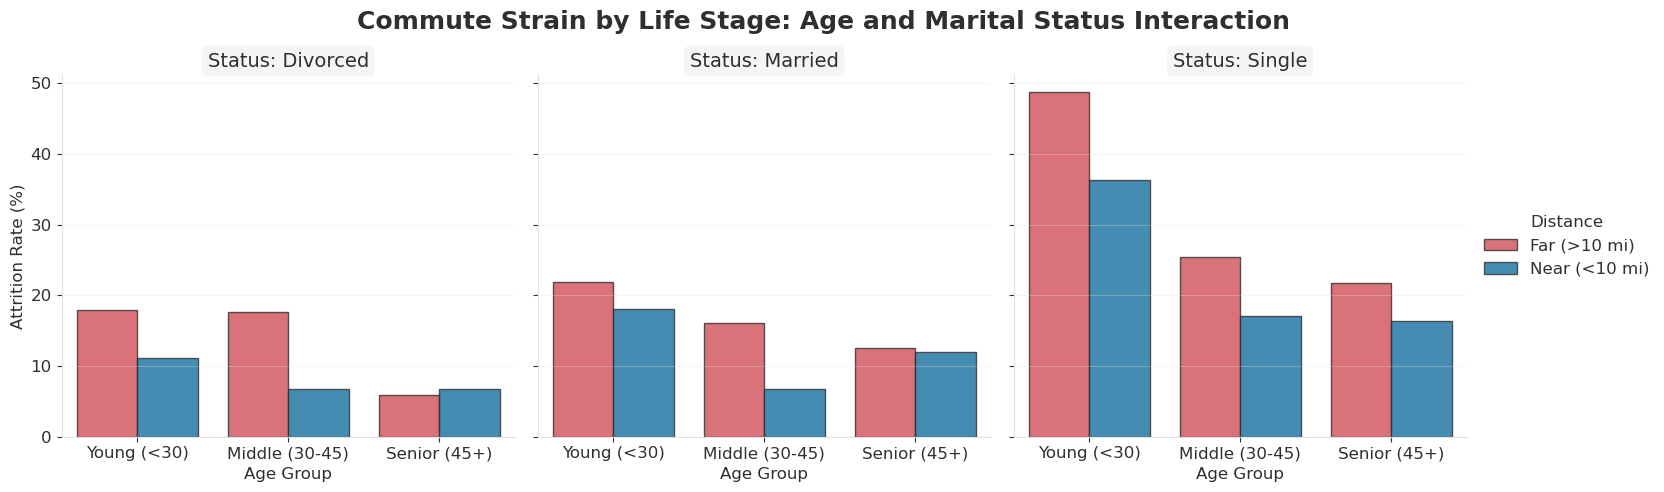

In [18]:
# Flatten the pivot table for Seaborn compatibility
plot_data = pivot_rq2.reset_index().melt(
    id_vars=['Marital Status', 'Age Group'], 
    value_vars=['Far (>10 mi)', 'Near (<10 mi)'], 
    var_name='Distance', 
    value_name='Attrition Rate'
)

# Visualization: Faceted Bar Chart for Marital Status
g = sns.catplot(
    data=plot_data, 
    kind="bar",
    x="Age Group", 
    y="Attrition Rate", 
    hue="Distance",
    col="Marital Status", 
    palette=[COLOR_ACCENT, COLOR_PRIMARY], # Red for 'Far', Blue for 'Near'
    alpha=0.8, 
    height=5, 
    aspect=1,
    edgecolor=COLOR_TEXT
)

# Formatting and Styling
g.set_axis_labels("Age Group", "Attrition Rate (%)")
g.set_titles("Status: {col_name}", fontweight='normal', size=14)
for ax in g.axes.flat:
    ax.title.set_bbox(dict(facecolor=COLOR_GRID, alpha=0.3, 
                           edgecolor='none', boxstyle='round,pad=0.3'))
  
# Add titles and adjust layout
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Commute Strain by Life Stage: Age and Marital Status Interaction', 
               fontsize=18, fontweight='bold', color=COLOR_TEXT)

plt.show()

**Interpretation of Results: The "Commute Sensitivity" Gap**

The interaction analysis reveals that commute distance is not a universal stressor; its impact is significantly moderated by an employee's life stage, specifically their marital status and age.

Key Observations:

* **Disproportionate Impact on Single Employees:** The most significant disparity between `Near` and `Far` commute attrition is observed in the Single category. For young, single employees, a long-distance commute correlates with the highest turnover rates in the entire dataset, often exceeding **40%**. This suggests that without the stabilizing influence of domestic ties, geographic strain becomes a primary catalyst for departure.
* **The "Married" Buffer:** Employees in the `Married` category exhibit much higher resilience to commute distance. The gap between "Near" and "Far" attrition rates is markedly narrower across all age groups compared to their single or divorced peers. This indicates that marital status acts as a moderating variable, providing a level of stability that offsets the stress of a long commute.
* **Age as a Resiliency Factor:** A clear downward trend in attrition is visible as age increases, regardless of distance or marital status. The `Senior` (**45+**) cohort shows the lowest overall attrition rates, even when residing further from the workplace. This likely reflects higher role seniority, greater career investment, and a general preference for stability in later career stages.
* **Commute Strain Gradient:** While the impact varies, the Far (**>10 mi**) bars (Red) are consistently higher than the Near (**<10 mi**) bars (Blue) in almost every demographic segment. This confirms that while life stages moderate the effect, distance remains a persistent risk factor across the organization.

### **Analytical Synthesis: Identifying the Attrition "Hot Zone"**

To conclude the investigation into Research Question 2, the analysis narrows its focus to the **Far (>10 mi)** commute group. By cross-referencing `Marital Status` and `Age Group` within this high-risk category, it is possible to isolate the "Critical Point" - the specific demographic intersection where the probability of attrition is at its peak.

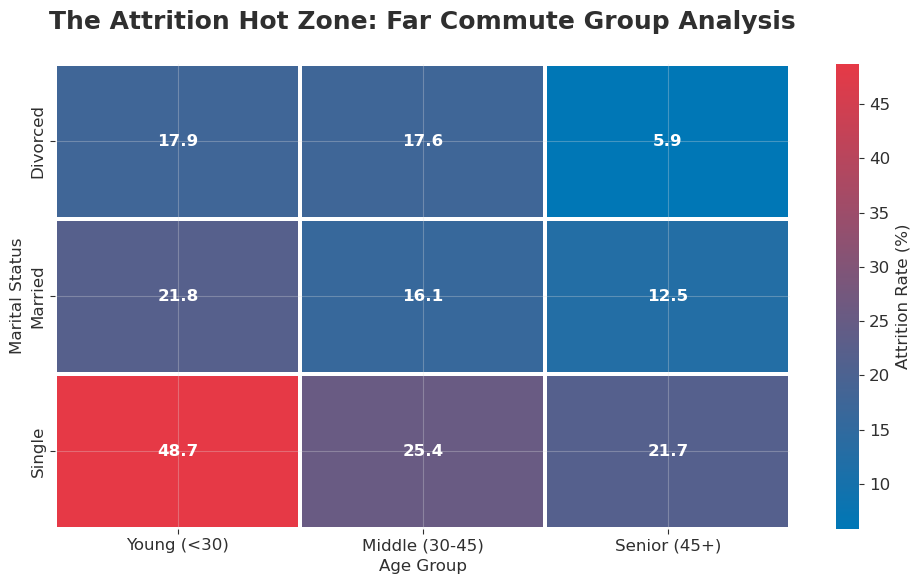

In [19]:
# Data Preparation for Heatmap 
# Focus on the "Far (>10 mi)" group as it was identified as high-risk
far_commute_df = df_attrition[df_attrition['Dist_Category'] == 'Far (>10 mi)'].copy()

# Create a pivot table for the Heatmap
heatmap_data = far_commute_df.pivot_table(observed=True,
    index='Marital Status', 
    columns='Age Group', 
    values='Attrition', 
    aggfunc='mean'
) * 100

# Visualization
custom_cmap = LinearSegmentedColormap.from_list("attrition_risk", [COLOR_PRIMARY, COLOR_ACCENT])
plt.figure(figsize=(10, 6))

# COLOR_ACCENT (Red) for the highest values
ax = sns.heatmap(
    heatmap_data, 
    annot=True,          # Show the actual % in the cells
    fmt=".1f",           # One decimal place
    cmap=custom_cmap,       # Yellow to Orange to Red (Standard for risk)
    cbar_kws={'label': 'Attrition Rate (%)'},
    linewidths=1.5,
    annot_kws={"weight": "bold", "size": 12}
)

# Formatting
plt.title('The Attrition Hot Zone: Far Commute Group Analysis', pad=25)
plt.xlabel('Age Group')
plt.ylabel('Marital Status')

plt.tight_layout()
plt.show()

**Interpretation: The Profile of Maximum Risk**

The heatmap identifies a high-intensity "Hot Zone" where turnover reaches levels that significantly exceed the organizational average.

Key Findings:

* **The High-Risk Core:** The intersection of `Single` employees and the `Young` (**<30**) age group represents the highest concentration of risk. In this segment, the attrition rate is at its maximum, suggesting that early-career individuals with long commutes and fewer domestic ties have the lowest threshold for geographic strain.
* **Age as a Stabilizer:** A consistent horizontal trend shows that as employees transition into Middle and Senior age brackets, their resilience to commute distance increases. Attrition rates drop significantly in the **45+** category, regardless of marital status.
* **Marital Moderation:** Within the high-strain "Far" group, `Married` employees consistently exhibit lower attrition rates than their `Single` or `Divorced` counterparts of the same age. This confirms that marital status acts as a powerful moderating variable, providing stability that offsets the negative impact of a long commute.

# **Final Project Conclusion and Recommendations**

This research aimed to evaluate the impact of workplace stressors and geographic strain on employee attrition, as well as the effectiveness of financial and demographic moderators.

## **Summary of Findings**

**Research Question 1 (Stressors & Income):**
The analysis confirms that `Overtime` and `Frequent Business Travel` are primary catalysts for attrition. However, `Monthly Income` serves as a critical buffer. Employees in high-stress roles are significantly more likely to remain with the organization if their compensation is above the identified median threshold (approx. `$5,000`). Attrition is most acute where high stress meets lower-tier compensation.

**Research Question 2 (Life Stage & Commute):**
While `Distance From Home` increases the baseline risk of turnover, its effect is heavily moderated by `Age` and `Marital Status`. The organization’s most vulnerable population consists of `young, single employees living more than 10 miles from the office`. Conversely, married and senior employees demonstrate much higher resilience to long-distance commutes.

## **Strategic Recommendations for HR:**

* **Targeted Retention Bonuses:** Instead of broad salary increases, implement retention incentives specifically for roles that require frequent travel or consistent overtime, particularly for those currently below the **$5,000** monthly income mark.
* **Geographic Flexibility:** Prioritize flexible work-from-home arrangements or "commute-offset" days for the identified **"Hot Zone"** (Single employees under 30 living 10+ miles away).
* **Relocation Support:** Consider relocation assistance for high-potential young talent to bring them within the **10-mile "Stability Zone"**, which showed the highest retention rates across all demographics.